# Review Analysis

## Review Score Distribution

This section examines the distribution of customer review scores and identifies patterns in customer satisfaction.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

reviews = pd.read_csv(
    DATA_DIR / "olist_order_reviews_dataset.csv"
)

In [2]:
reviews.shape

(99224, 7)

In [3]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [4]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [5]:
review_summary = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="reviews")
)

review_summary["share"] = (
    review_summary["reviews"]
    / review_summary["reviews"].sum()
)

review_summary

,review_score,reviews,share
0,1,11424,0.115133
1,2,3151,0.031756
2,3,8179,0.082430
3,4,19142,0.192917
4,5,57328,0.577763


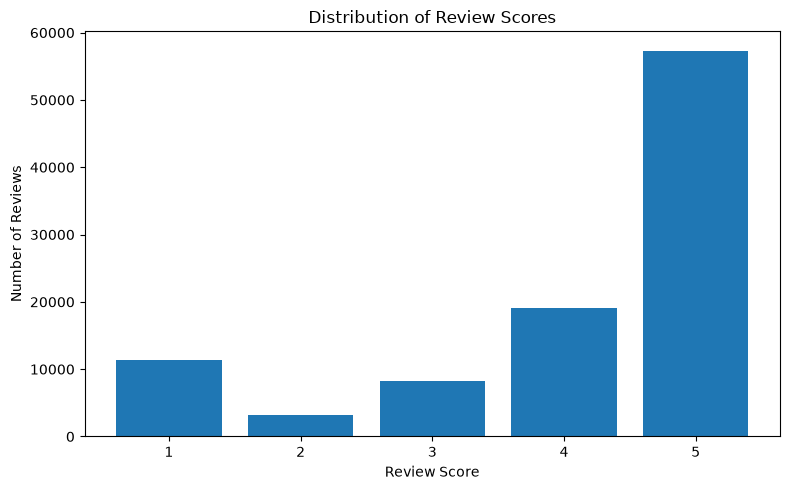

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    review_summary["review_score"],
    review_summary["reviews"]
)

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

In [7]:
review_score_summary = {
    "avg_review_score": reviews["review_score"].mean(),
    "median_review_score": reviews["review_score"].median(),
    "positive_review_rate": (
        reviews["review_score"].ge(4).mean()
    ),
    "negative_review_rate": (
        reviews["review_score"].le(2).mean()
    )
}

review_score_summary

{'avg_review_score': np.float64(4.08642062404257),
 'median_review_score': np.float64(5.0),
 'positive_review_rate': np.float64(0.7706804805289043),
 'negative_review_rate': np.float64(0.14688986535515602)}

## Key Finding

Customer reviews are strongly skewed toward positive ratings. The average review score is 4.09, with a median of 5. Overall, 77.1% of reviews are positive (4 or 5), while 14.7% are negative (1 or 2).

In [8]:
review_order_counts = reviews["order_id"].value_counts()

review_order_counts.value_counts()

count
1    98126
2      543
3        4
Name: count, dtype: int64

In [9]:
review_order_counts.max()

np.int64(3)

In [10]:
order_reviews = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean")
    )
    .reset_index()
)

order_reviews.shape

(98673, 2)

In [11]:
order_reviews["order_id"].nunique()

98673

In [12]:
order_reviews["review_score"].isna().sum()

np.int64(0)

## Delivery Performance and Review Score

This section examines the relationship between delivery performance and customer review scores.

In [13]:
orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv"
)

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [14]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivered_orders["delivery_status"] = (
    delivered_orders["delivery_delay_days"]
    > 0
).map({
    True: "Late",
    False: "On-time"
})

In [15]:
delivery_reviews = delivered_orders[
    ["order_id", "delivery_days", "delivery_delay_days", "delivery_status"]
].merge(
    order_reviews,
    on="order_id",
    how="inner"
)

delivery_reviews.shape

(95832, 5)

In [16]:
delivery_reviews["delivery_status"].value_counts()

delivery_status
On-time    88171
Late        7661
Name: count, dtype: int64

In [17]:
delivery_reviews["review_score"].isna().sum()

np.int64(0)

In [18]:
review_by_delivery = (
    delivery_reviews
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "count"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
    .sort_values("avg_review_score")
)

review_by_delivery

,orders,avg_review_score,median_review_score
delivery_status,,,
Late,7661,2.566506,2.0
On-time,88171,4.294311,5.0


In [19]:
review_by_delivery["review_score_difference"] = (
    review_by_delivery["avg_review_score"]
    - review_by_delivery["avg_review_score"].loc["On-time"]
)

review_by_delivery

,orders,avg_review_score,median_review_score,review_score_difference
delivery_status,,,,
Late,7661,2.566506,2.0,-1.727805
On-time,88171,4.294311,5.0,0.000000


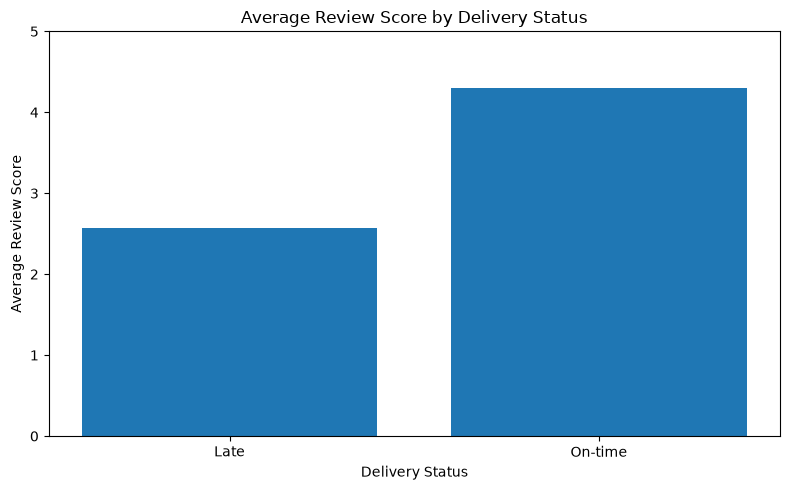

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    review_by_delivery.index,
    review_by_delivery["avg_review_score"]
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

## Key Finding

Late deliveries are strongly associated with lower customer review scores. Orders delivered on time received an average review score of 4.29, compared with 2.57 for late deliveries — a difference of 1.73 points.

This analysis shows a strong association between delivery performance and customer satisfaction, but does not establish a causal relationship.

In [21]:
delivery_reviews["delivery_days"].describe()

count    95824.000000
mean        12.516765
std          9.460505
min          0.533414
25%          6.757214
50%         10.206059
75%         15.663542
max        208.351759
Name: delivery_days, dtype: float64

In [22]:
delivery_reviews["delivery_days"].isna().sum()

np.int64(8)

In [23]:
delivery_reviews["delivery_time_group"] = pd.qcut(
    delivery_reviews["delivery_days"],
    q=4,
    labels=[
        "Fastest 25%",
        "25%-50%",
        "50%-75%",
        "Slowest 25%"
    ]
)

In [24]:
review_by_delivery_time = (
    delivery_reviews
    .groupby("delivery_time_group", observed=False)
    .agg(
        orders=("order_id", "count"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
)

review_by_delivery_time

,orders,avg_review_score,median_review_score
delivery_time_group,,,
Fastest 25%,23956,4.419721,5.0
25%-50%,23956,4.349724,5.0
50%-75%,23956,4.258015,5.0
Slowest 25%,23956,3.597171,4.0


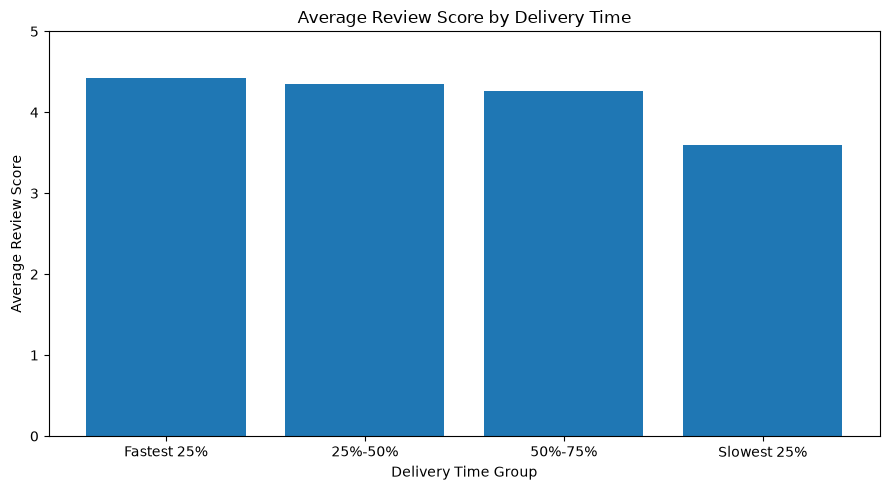

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    review_by_delivery_time.index,
    review_by_delivery_time["avg_review_score"]
)

plt.title("Average Review Score by Delivery Time")
plt.xlabel("Delivery Time Group")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

## Key Finding

Customer review scores decline as delivery time increases. The fastest 25% of orders received an average review score of 4.42, compared with 3.60 for the slowest 25% — a difference of 0.82 points.

This pattern indicates a strong association between longer delivery times and lower customer satisfaction.